# Hybrid Newton-Net + Amortized Variational Inference

End-to-end pipeline for training a Transformer-based inference network on
GMM tau-p reflectivity data, then using the network's posterior as a warm
start for full-Newton Levenberg-Marquardt inversion.

**Steps:**
1. Load YAML configuration
2. Generate training data (perturbed earth models + GMM forward)
3. Train the SeismicInferenceNet (AdamW + cosine annealing + early stopping)
4. Evaluate on held-out test set (NLL, MAE, calibration)
5. Run hybrid inversion (network warm start + Newton refinement)
6. Compare convergence against random-start inversion

In [ ]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
print(f"Backend: {matplotlib.get_backend()}")
print(f"Interactive: {matplotlib.is_interactive()}")

# Ensure the project root is on sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

logging.basicConfig(level=logging.INFO, format="%(message)s")

## Load Configuration

In [2]:
from NeuralInversion.inference_config import load_inference_config

cfg = load_inference_config(Path("configs/default_inference.yaml"))

# Architecture summary
a = cfg.architecture
print(
    f"Architecture: d_model={a.d_model}, n_heads={a.n_heads}, "
    f"n_layers={a.n_layers}, d_ff={a.d_ff}, dropout={a.dropout}"
)

# Training summary
t = cfg.training
print(
    f"Training:     epochs={t.n_epochs}, batch_size={t.batch_size}, "
    f"lr={t.learning_rate:.0e}, patience={t.patience}"
)

# Data summary
d = cfg.data
print(f"Data:         train={d.n_train}, val={d.n_val}, test={d.n_test}")
print(f"              p_values={len(d.p_values)} slownesses, nfreq={d.nfreq}")
print(
    f"              perturbations: vel={d.velocity_perturbation:.0%}, "
    f"rho={d.density_perturbation:.0%}, h={d.thickness_perturbation:.0%}"
)

Architecture: d_model=64, n_heads=4, n_layers=3, d_ff=128, dropout=0.1
Training:     epochs=200, batch_size=256, lr=1e-03, patience=20
Data:         train=50000, val=5000, test=5000
              p_values=12 slownesses, nfreq=64
              perturbations: vel=20%, rho=15%, h=25%


## Generate Training Data

In [3]:
import time

import torch

from Kennett_Reflectivity.kennett_seismogram import default_ocean_crust_model

from NeuralInversion.inference_data import generate_training_data

ref_model = default_ocean_crust_model()

t0 = time.perf_counter()
paths = generate_training_data(cfg.data_dir, cfg.data, ref_model=ref_model)
datagen_time = time.perf_counter() - t0

for split, path in paths.items():
    data = torch.load(path, weights_only=True)
    n = data["log_params"].shape[0]
    r_shape = data["reflectivity"].shape
    print(
        f"{split:>5}: {n:,} samples, "
        f"reflectivity {r_shape[1:]} (n_p x 2*nfreq), "
        f"params {data['log_params'].shape[1]}"
    )

print(f"\nData generation: {datagen_time:.1f} s")

train_path = paths["train"]
val_path = paths["val"]
test_path = paths["test"]

train: 1000/50000
train: 2000/50000
train: 3000/50000
train: 4000/50000
train: 5000/50000
train: 6000/50000
train: 7000/50000
train: 8000/50000
train: 9000/50000
train: 10000/50000
train: 11000/50000
train: 12000/50000
train: 13000/50000
train: 14000/50000
train: 15000/50000
train: 16000/50000
train: 17000/50000
train: 18000/50000
train: 19000/50000
train: 20000/50000
train: 21000/50000
train: 22000/50000
train: 23000/50000
train: 24000/50000
train: 25000/50000
train: 26000/50000
train: 27000/50000
train: 28000/50000
train: 29000/50000
train: 30000/50000
train: 31000/50000
train: 32000/50000
train: 33000/50000
train: 34000/50000
train: 35000/50000
train: 36000/50000
train: 37000/50000
train: 38000/50000
train: 39000/50000
train: 40000/50000
train: 41000/50000
train: 42000/50000
train: 43000/50000
train: 44000/50000
train: 45000/50000
train: 46000/50000
train: 47000/50000
train: 48000/50000
train: 49000/50000
train: 50000/50000
Saved train: 50000 samples -> data/train.pt
val: 1000/5000


train: 50,000 samples, reflectivity torch.Size([12, 128]) (n_p x 2*nfreq), params 15
  val: 5,000 samples, reflectivity torch.Size([12, 128]) (n_p x 2*nfreq), params 15
 test: 5,000 samples, reflectivity torch.Size([12, 128]) (n_p x 2*nfreq), params 15

Data generation: 4746.9 s


## Train Network

In [4]:
from NeuralInversion.inference_train import train_inference_net

t0 = time.perf_counter()
model, history = train_inference_net(cfg, train_path, val_path)
training_time = time.perf_counter() - t0

best_epoch = int(np.argmin(history["val_loss"])) + 1
best_val = min(history["val_loss"])
print(f"\nBest epoch: {best_epoch}")
print(f"Best val loss: {best_val:.4f}")
print(f"Total epochs trained: {len(history['train_loss'])}")
print(f"Training time: {training_time:.1f} s")

epoch   1  train=-20.7136  val=-32.5265  lr=1.00e-03
epoch   2  train=-33.2457  val=-35.5175  lr=1.00e-03
epoch   3  train=-35.6850  val=-37.1004  lr=1.00e-03
epoch   4  train=-37.2719  val=-38.9854  lr=9.99e-04
epoch   5  train=-38.6076  val=-41.7918  lr=9.99e-04
epoch   6  train=-39.9357  val=-41.9310  lr=9.98e-04
epoch   7  train=-40.7764  val=-43.1781  lr=9.98e-04
epoch   8  train=-41.6921  val=-44.5799  lr=9.97e-04
epoch   9  train=-42.4543  val=-45.7202  lr=9.96e-04
epoch  10  train=-42.9088  val=-45.4094  lr=9.95e-04
epoch  11  train=-43.4023  val=-46.1901  lr=9.94e-04
epoch  12  train=-44.3204  val=-46.4707  lr=9.93e-04
epoch  13  train=-44.5343  val=-47.1232  lr=9.91e-04
epoch  14  train=-45.1526  val=-47.7318  lr=9.90e-04
epoch  15  train=-45.4958  val=-48.3445  lr=9.88e-04
epoch  16  train=-45.8546  val=-48.6264  lr=9.86e-04
epoch  17  train=-46.1920  val=-49.1282  lr=9.84e-04
epoch  18  train=-46.5770  val=-49.9793  lr=9.82e-04
epoch  19  train=-46.6663  val=-49.3569  lr=9.


Best epoch: 194
Best val loss: -62.4715
Total epochs trained: 200
Training time: 3321.8 s


## Training Curves

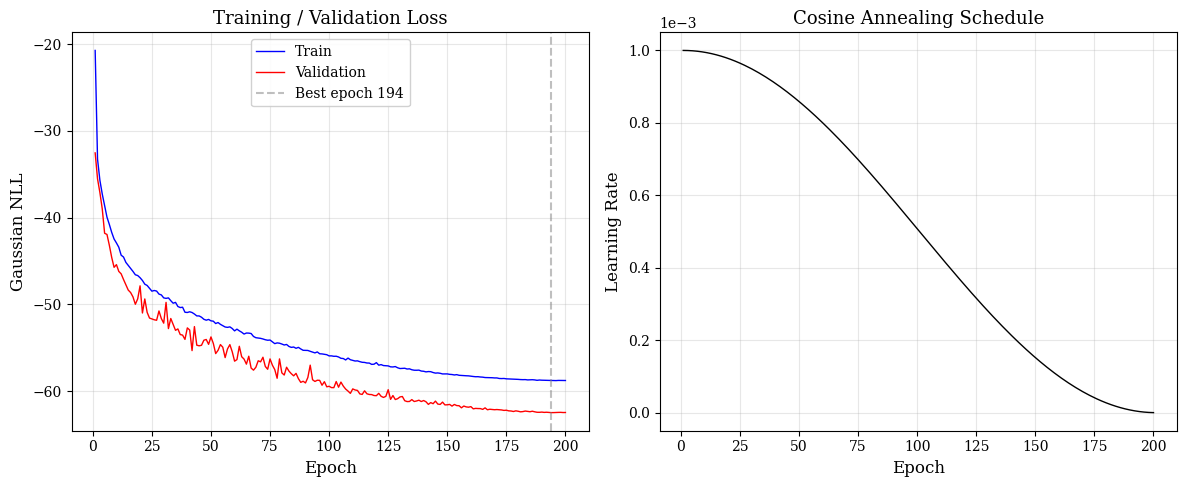

In [5]:
from Kennett_Reflectivity.taup_inversion import _LATEX_RCPARAMS

epochs = np.arange(1, len(history["train_loss"]) + 1)

with plt.rc_context(_LATEX_RCPARAMS):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Loss curves
    ax1.plot(epochs, history["train_loss"], "b-", label="Train", linewidth=1.0)
    ax1.plot(epochs, history["val_loss"], "r-", label="Validation", linewidth=1.0)
    ax1.axvline(
        best_epoch,
        color="gray",
        linestyle="--",
        alpha=0.5,
        label=f"Best epoch {best_epoch}",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Gaussian NLL")
    ax1.set_title("Training / Validation Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Learning rate schedule
    ax2.plot(epochs, history["learning_rate"], "k-", linewidth=1.0)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Cosine Annealing Schedule")
    ax2.ticklabel_format(axis="y", style="sci", scilimits=(-3, -3))
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

## Evaluate on Test Set

In [6]:
from NeuralInversion.inference_train import evaluate_inference_net

metrics = evaluate_inference_net(model, test_path)

print(f"Test NLL:              {metrics['nll']:.4f}")
print(f"Mean absolute error:   {metrics['mean_abs_error']:.4f}")
print(f"Calibration (2-sigma): {metrics['calibration_2sigma']:.1%}")

Test NLL:              -62.6912
Mean absolute error:   0.0083
Calibration (2-sigma): 99.5%


## Hybrid Inversion

In [7]:
from NeuralInversion.hybrid_inversion import hybrid_invert_taup

true_model = default_ocean_crust_model()

t0 = time.perf_counter()
hybrid_result = hybrid_invert_taup(
    true_model=true_model,
    model=model,
    p_values=cfg.data.p_values,
    nfreq=cfg.data.nfreq,
    max_iter=cfg.hybrid.max_newton_iter,
    tol=cfg.hybrid.newton_tol,
    initial_damping=cfg.hybrid.initial_damping,
    use_laplace=cfg.hybrid.use_laplace,
)
hybrid_time = time.perf_counter() - t0

inv = hybrid_result.inversion_result
print(f"\nNetwork param error: {hybrid_result.network_param_error:.4e}")
print(f"Converged: {inv.converged}")
print(f"Newton iterations: {hybrid_result.newton_iterations}")
print(f"Final misfit: {inv.misfit_history[-1]:.2e}")
print(f"Final param error: {inv.param_error_history[-1]:.4e}")
print(f"Hybrid inversion time: {hybrid_time:.2f} s")

Network prediction: param_error=2.1991e-03
iter   0  chi=6.7682e-02  ||g||=1.7028e+02  err=2.1991e-03
iter   1  chi=5.5818e-03  ||g||=3.4233e+00  err=2.0205e-03
iter   2  chi=2.5179e-03  ||g||=1.2199e+00  err=1.8651e-03
iter   3  chi=1.4179e-03  ||g||=5.4740e-01  err=1.6566e-03
iter   4  chi=8.1779e-04  ||g||=3.0717e-01  err=1.3725e-03
iter   5  chi=4.0654e-04  ||g||=1.7922e-01  err=1.0359e-03
iter   6  chi=1.6031e-04  ||g||=9.6541e-02  err=6.7823e-04
iter   7  chi=4.1707e-05  ||g||=4.6459e-02  err=3.4989e-04
iter   8  chi=5.3372e-06  ||g||=1.6577e-02  err=1.2574e-04
iter   9  chi=2.6066e-07  ||g||=3.5654e-03  err=2.8228e-05



Network param error: 2.1991e-03
Converged: True
Newton iterations: 10
Final misfit: 2.61e-07
Final param error: 2.8228e-05
Hybrid inversion time: 28.68 s


## Comparison: Hybrid vs Random Start

In [8]:
from GlobalMatrix.taup_inversion import invert_taup

t0 = time.perf_counter()
random_result = invert_taup(
    true_model=true_model,
    p_values=cfg.data.p_values,
    nfreq=cfg.data.nfreq,
    perturbation=cfg.data.velocity_perturbation,
    max_iter=50,
    seed=cfg.data.seed,
)
random_time = time.perf_counter() - t0

print(f"\n{'':>20} {'Hybrid':>10} {'Random':>10}")
print("-" * 42)
print(
    f"{'Iterations':>20} {hybrid_result.newton_iterations:>10} "
    f"{random_result.n_iterations:>10}"
)
print(f"{'Converged':>20} {str(inv.converged):>10} {str(random_result.converged):>10}")
print(
    f"{'Final misfit':>20} {inv.misfit_history[-1]:>10.2e} "
    f"{random_result.misfit_history[-1]:>10.2e}"
)
print(
    f"{'Final param error':>20} {inv.param_error_history[-1]:>10.4e} "
    f"{random_result.param_error_history[-1]:>10.4e}"
)
print(f"{'Wall time (s)':>20} {hybrid_time:>10.2f} {random_time:>10.2f}")

iter   0  chi=2.3125e+02  ||g||=1.3307e+03  err=1.0518e-01
iter   1  chi=1.5425e+02  ||g||=8.3352e+02  err=8.0220e-02
iter   2  chi=1.2792e+02  ||g||=9.2949e+02  err=7.4940e-02
iter   3  chi=1.0587e+02  ||g||=9.7357e+02  err=9.3694e-02
iter   4  chi=9.8544e+01  ||g||=1.2722e+03  err=9.3696e-02
iter   5  chi=4.9882e+01  ||g||=1.8103e+03  err=9.3751e-02
iter   6  chi=3.5575e+01  ||g||=1.4327e+03  err=9.3724e-02
iter   7  chi=2.6619e+01  ||g||=6.5481e+02  err=9.3586e-02
iter   8  chi=2.3517e+01  ||g||=3.3346e+02  err=9.3249e-02
iter   9  chi=2.0797e+01  ||g||=2.4717e+02  err=9.2632e-02
iter  10  chi=1.7815e+01  ||g||=1.8426e+02  err=9.1618e-02
iter  11  chi=1.4455e+01  ||g||=1.3848e+02  err=9.0045e-02
iter  12  chi=1.0743e+01  ||g||=1.0224e+02  err=8.7668e-02
iter  13  chi=7.0245e+00  ||g||=7.0748e+01  err=8.3899e-02
iter  14  chi=4.0558e+00  ||g||=4.3913e+01  err=7.7297e-02
iter  15  chi=2.1490e+00  ||g||=2.6432e+01  err=6.5108e-02
iter  16  chi=9.6302e-01  ||g||=1.4223e+01  err=4.4428e-


                         Hybrid     Random
------------------------------------------
          Iterations         10         28
           Converged       True       True
        Final misfit   2.61e-07   1.42e-22
   Final param error 2.8228e-05 1.0588e-12
       Wall time (s)      28.68      80.85


## Convergence Comparison

## Amortized Cost Analysis

The hybrid approach has a large upfront cost (data generation + training) that
must be amortized over many inversions to break even against the random-start
Newton solver. Below we compute the break-even point.

In [9]:
upfront_cost = datagen_time + training_time
time_saved_per_inversion = random_time - hybrid_time

print("Wall-clock budget")
print("=" * 50)
print(f"  Data generation:        {datagen_time:>8.1f} s")
print(f"  Network training:       {training_time:>8.1f} s")
print(f"  Total upfront cost:     {upfront_cost:>8.1f} s")
print()
print(f"  Single hybrid inversion:  {hybrid_time:>6.2f} s")
print(f"  Single random inversion:  {random_time:>6.2f} s")
print(f"  Time saved per inversion: {time_saved_per_inversion:>6.2f} s")
print()

if time_saved_per_inversion > 0:
    breakeven = int(np.ceil(upfront_cost / time_saved_per_inversion))
    print(f"  Break-even after {breakeven:,} inversions")
else:
    breakeven = None
    print("  Hybrid is slower per-inversion — no break-even point")

print()
print("The hybrid approach is justified when:")
print("  1. Many inversions share the same model class (amortized inference)")
print("  2. The network provides calibrated uncertainty (free posterior)")
print("  3. Multi-modal posteriors risk trapping random-start Newton")

Wall-clock budget
  Data generation:          4746.9 s
  Network training:         3321.8 s
  Total upfront cost:       8068.7 s

  Single hybrid inversion:   28.68 s
  Single random inversion:   80.85 s
  Time saved per inversion:  52.17 s

  Break-even after 155 inversions

The hybrid approach is justified when:
  1. Many inversions share the same model class (amortized inference)
  2. The network provides calibrated uncertainty (free posterior)
  3. Multi-modal posteriors risk trapping random-start Newton


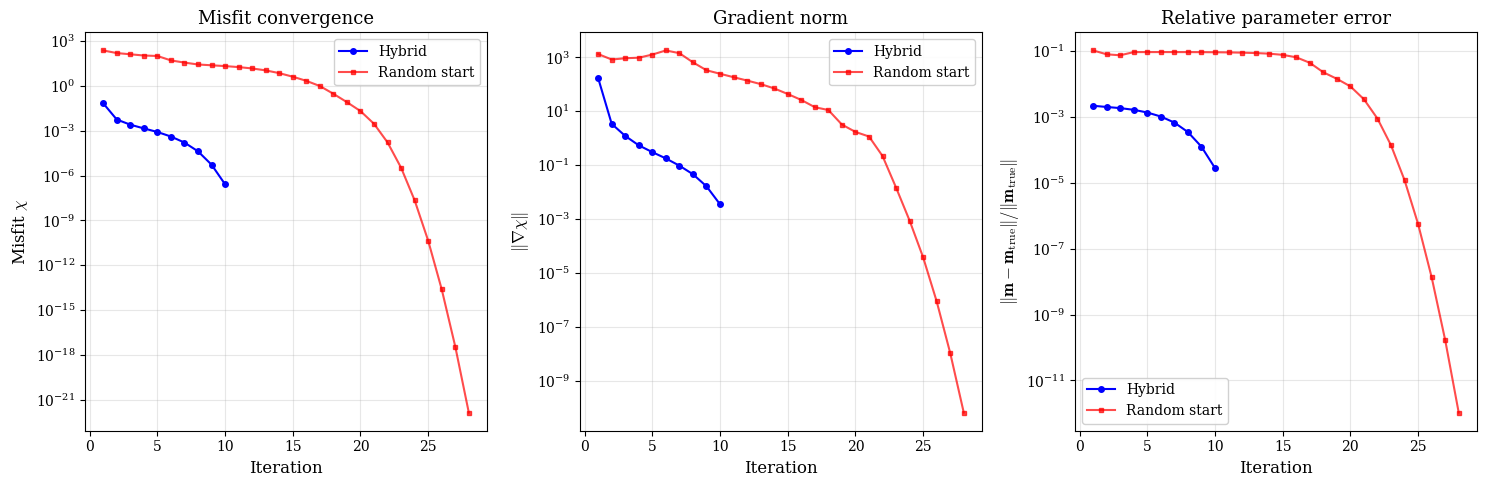

In [10]:
with plt.rc_context(_LATEX_RCPARAMS):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    h_iters = np.arange(1, len(inv.misfit_history) + 1)
    r_iters = np.arange(1, len(random_result.misfit_history) + 1)

    # Misfit
    axes[0].semilogy(h_iters, inv.misfit_history, "b-o", markersize=4, label="Hybrid")
    axes[0].semilogy(
        r_iters,
        random_result.misfit_history,
        "r-s",
        markersize=3,
        alpha=0.7,
        label="Random start",
    )
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel(r"Misfit $\chi$")
    axes[0].set_title("Misfit convergence")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Gradient norm
    axes[1].semilogy(
        h_iters, inv.grad_norm_history, "b-o", markersize=4, label="Hybrid"
    )
    axes[1].semilogy(
        r_iters,
        random_result.grad_norm_history,
        "r-s",
        markersize=3,
        alpha=0.7,
        label="Random start",
    )
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel(r"$\|\nabla\chi\|$")
    axes[1].set_title("Gradient norm")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Parameter error
    axes[2].semilogy(
        h_iters, inv.param_error_history, "b-o", markersize=4, label="Hybrid"
    )
    axes[2].semilogy(
        r_iters,
        random_result.param_error_history,
        "r-s",
        markersize=3,
        alpha=0.7,
        label="Random start",
    )
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel(
        r"$\|\mathbf{m} - \mathbf{m}_\mathrm{true}\|"
        r" / \|\mathbf{m}_\mathrm{true}\|$"
    )
    axes[2].set_title("Relative parameter error")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

## Uncertainty Estimates

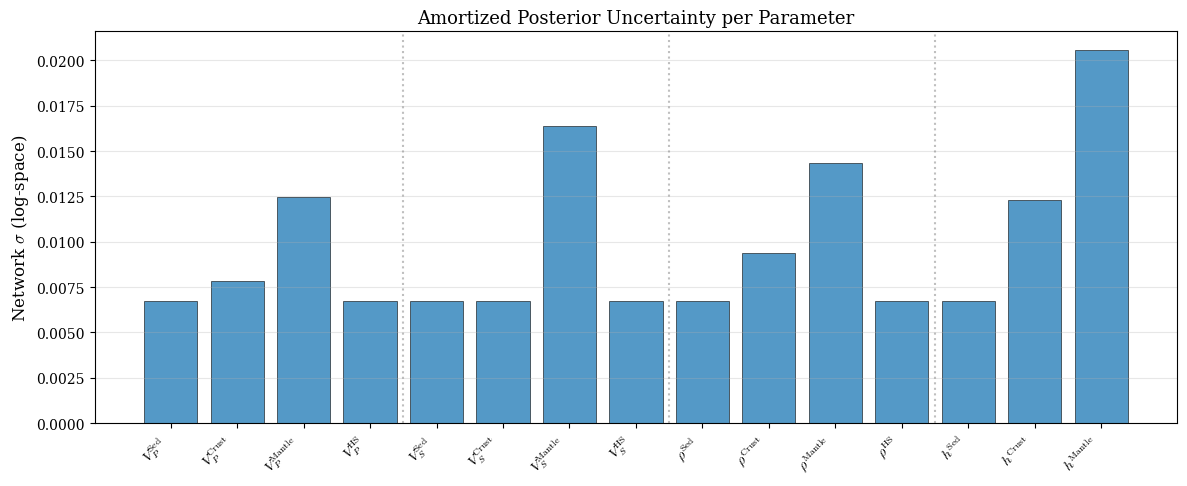

In [11]:
# Parameter names: Vp(1-4), Vs(1-4), rho(1-4), h(1-3)
layer_names = ["Sed", "Crust", "Mantle", "HS"]
param_names = (
    [f"$V_P^\\mathrm{{{n}}}$" for n in layer_names]
    + [f"$V_S^\\mathrm{{{n}}}$" for n in layer_names]
    + [f"$\\rho^\\mathrm{{{n}}}$" for n in layer_names]
    + [f"$h^\\mathrm{{{n}}}$" for n in layer_names[:3]]
)

sigma = hybrid_result.network_sigma
x_pos = np.arange(len(param_names))

with plt.rc_context(_LATEX_RCPARAMS):
    fig, ax = plt.subplots(figsize=(12, 5))

    bars = ax.bar(
        x_pos, sigma, color="#2980b9", edgecolor="black", linewidth=0.5, alpha=0.8
    )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(param_names, rotation=45, ha="right")
    ax.set_ylabel(r"Network $\sigma$ (log-space)")
    ax.set_title("Amortized Posterior Uncertainty per Parameter")
    ax.grid(True, alpha=0.3, axis="y")

    # Group separators
    for boundary in [3.5, 7.5, 11.5]:
        ax.axvline(boundary, color="gray", linestyle=":", alpha=0.5)

    fig.tight_layout()
    plt.show()

## Model Comparison: True vs Network Start vs Recovered

In [13]:
layer_names_full = ["Ocean", "Sediment", "Crust", "Upper mantle", "Half-space"]

header = (
    f"{'Layer':<15} {'Param':>6} {'True':>8} {'Net Start':>10} "
    f"{'Recovered':>10} {'Error %':>8}"
)
print(header)
print("-" * len(header))

for i in range(inv.true_model.n_layers):
    name = layer_names_full[i]
    for param, label in [
        ("alpha", "Vp"),
        ("beta", "Vs"),
        ("rho", "rho"),
        ("thickness", "h"),
    ]:
        t_val = getattr(inv.true_model, param)[i]
        i_val = getattr(inv.initial_model, param)[i]
        r_val = getattr(inv.recovered_model, param)[i]

        if np.isinf(t_val):
            print(
                f"{name:<15} {label:>6} {'inf':>8} {'inf':>10} "
                f"{'inf':>10} {'---':>8}"
            )
        else:
            err = abs(r_val - t_val) / max(abs(t_val), 1e-30) * 100
            print(
                f"{name:<15} {label:>6} {t_val:8.4f} {i_val:10.4f} "
                f"{r_val:10.4f} {err:8.2e}"
            )
        name = ""  # only print layer name on first row

Layer            Param     True  Net Start  Recovered  Error %
--------------------------------------------------------------
Ocean               Vp   1.5000     1.5000     1.5000 0.00e+00
                    Vs   0.0000     0.0000     0.0000 0.00e+00
                   rho   1.0000     1.0000     1.0000 0.00e+00
                     h   2.0000     2.0000     2.0000 0.00e+00
Sediment            Vp   1.6000     1.5992     1.6000 2.32e-05
                    Vs   0.3000     0.3005     0.3000 4.74e-05
                   rho   2.0000     1.9985     2.0000 1.31e-04
                     h   1.0000     1.0010     1.0000 5.28e-05
Crust               Vp   3.0000     2.9988     3.0000 1.03e-04
                    Vs   1.5000     1.5023     1.5000 1.72e-04
                   rho   3.0000     3.0021     3.0000 4.24e-04
                     h   1.0000     1.0005     1.0000 6.30e-04
Upper mantle        Vp   5.0000     5.0003     5.0000 6.30e-05
                    Vs   3.0000     3.0156     3.0000 7

## Depth Profiles

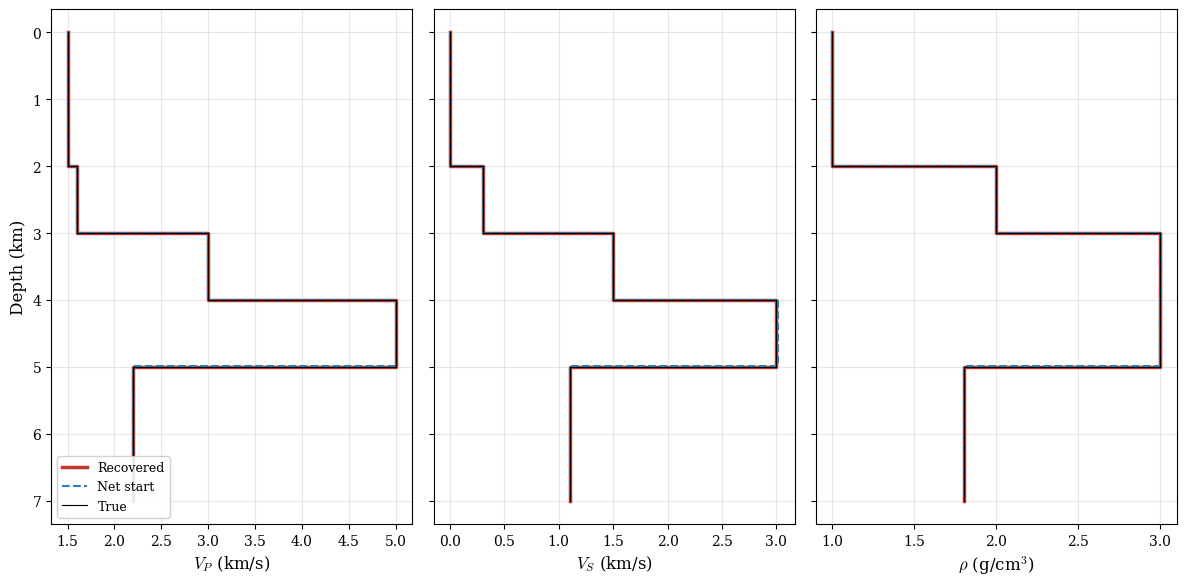

In [18]:
from IPython.display import display

from Kennett_Reflectivity.taup_inversion import _depth_profile

params = [
    ("alpha", r"$V_P$ (km/s)"),
    ("beta", r"$V_S$ (km/s)"),
    ("rho", r"$\rho$ (g/cm$^3$)"),
]

# Plot order: widest first so narrower lines are visible on top
models = [
    (inv.recovered_model, "Recovered", "#c0392b", "-", 2.5),
    (inv.initial_model, "Net start", "#2980b9", "--", 1.5),
    (inv.true_model, "True", "black", "-", 0.8),
]

with plt.rc_context(_LATEX_RCPARAMS):
    fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

    for ax, (param, xlabel) in zip(axes, params):
        for mdl, label, color, ls, lw in models:
            depths, values = _depth_profile(mdl, param)
            ax.plot(
                values, depths, color=color, linestyle=ls, linewidth=lw, label=label
            )
        ax.set_xlabel(xlabel)
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Depth (km)")
    axes[0].legend(loc="lower left", fontsize=9)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## Tau-p Trace Comparison

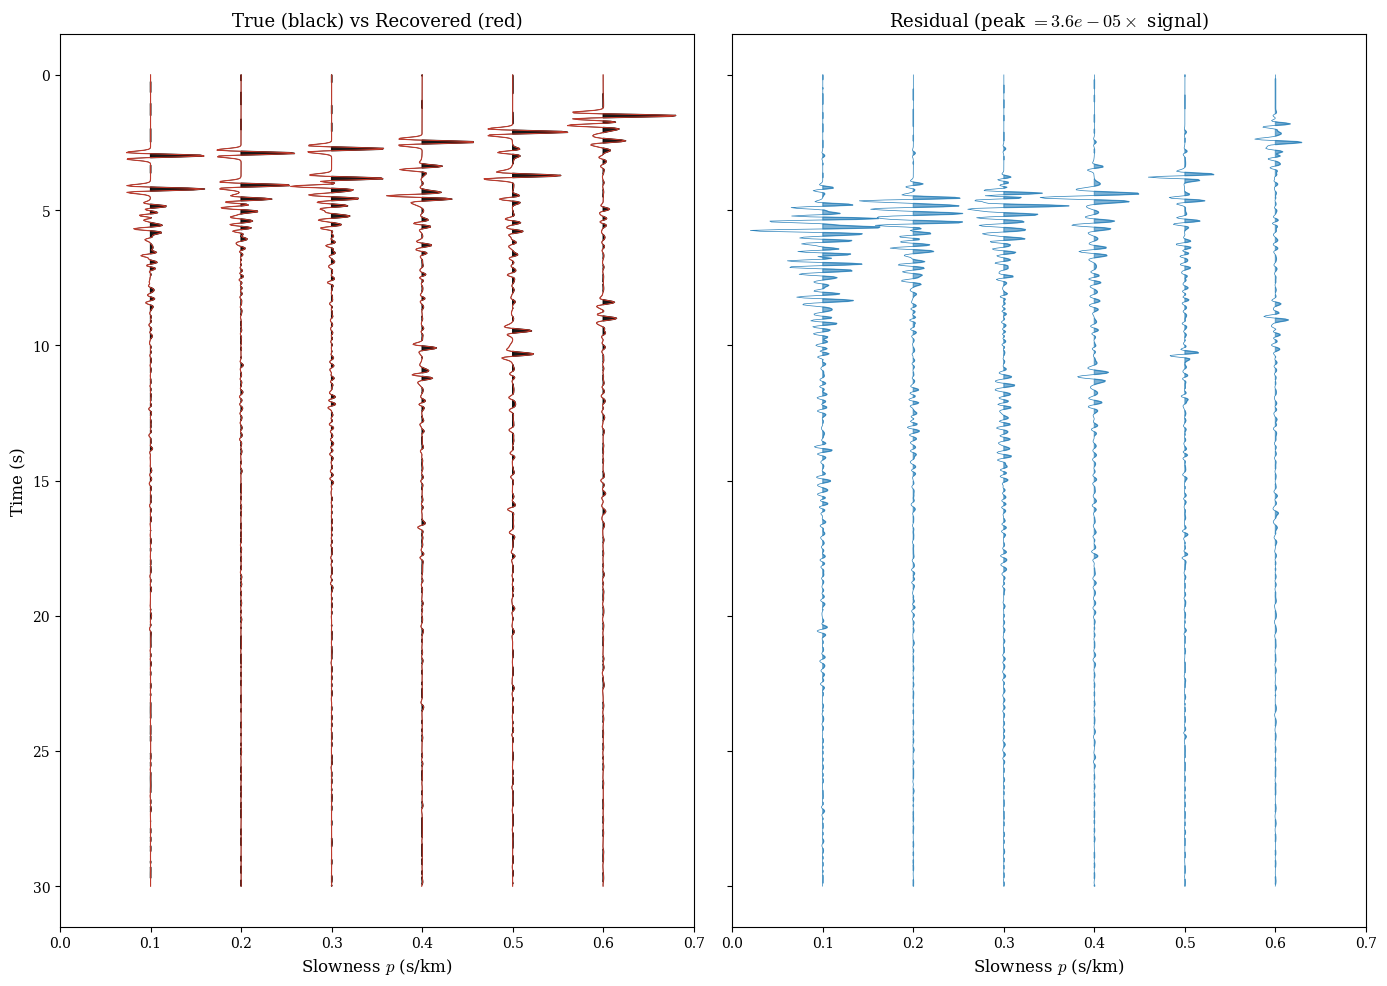

In [17]:
from GlobalMatrix.taup_inversion import compute_taup_traces

p_plot = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
nw = 1024
t_max = 30.0

_, traces_true = compute_taup_traces(inv.true_model, p_plot, nw=nw)
_, traces_rec = compute_taup_traces(inv.recovered_model, p_plot, nw=nw)
time_arr = np.arange(2 * nw, dtype=np.float64) * (64.0 / (2 * nw))

tmask = time_arr <= t_max
t_plot = time_arr[tmask]
global_peak = max(np.abs(traces_true[p][tmask]).max() for p in p_plot)
dp = p_plot[1] - p_plot[0]
clip = 0.8

with plt.rc_context(_LATEX_RCPARAMS):
    fig, (ax_main, ax_res) = plt.subplots(1, 2, figsize=(14, 10), sharey=True)

    for p_val in p_plot:
        tr_t = traces_true[p_val][tmask].copy()
        tr_r = traces_rec[p_val][tmask].copy()
        if global_peak > 0:
            tr_t = tr_t / global_peak * dp * clip
            tr_r = tr_r / global_peak * dp * clip

        ax_main.plot(p_val + tr_t, t_plot, "k-", linewidth=0.4)
        ax_main.fill_betweenx(
            t_plot,
            p_val,
            p_val + tr_t,
            where=(tr_t > 0),
            interpolate=True,
            color="black",
            alpha=0.9,
        )
        ax_main.plot(p_val + tr_r, t_plot, color="#c0392b", linewidth=0.8)

    ax_main.set_xlabel(r"Slowness $p$ (s/km)")
    ax_main.set_ylabel("Time (s)")
    ax_main.set_title("True (black) vs Recovered (red)")
    ax_main.invert_yaxis()
    ax_main.set_xlim(p_plot[0] - dp, p_plot[-1] + dp)

    # Residual
    res_peak = max(
        np.abs(traces_true[p][tmask] - traces_rec[p][tmask]).max() for p in p_plot
    )
    res_scale = global_peak if res_peak == 0 else res_peak

    for p_val in p_plot:
        residual = traces_true[p_val][tmask] - traces_rec[p_val][tmask]
        if res_scale > 0:
            residual = residual / res_scale * dp * clip
        ax_res.plot(p_val + residual, t_plot, color="#2980b9", linewidth=0.5)
        ax_res.fill_betweenx(
            t_plot,
            p_val,
            p_val + residual,
            where=(residual > 0),
            interpolate=True,
            color="#2980b9",
            alpha=0.6,
        )

    if global_peak > 0 and res_peak > 0:
        ratio = res_peak / global_peak
        ax_res.set_title(rf"Residual (peak $= {ratio:.1e} \times$ signal)")
    else:
        ax_res.set_title("Residual")
    ax_res.set_xlabel(r"Slowness $p$ (s/km)")
    ax_res.set_xlim(p_plot[0] - dp, p_plot[-1] + dp)

    fig.tight_layout()
    display(fig)
    plt.close(fig)

## Export Results

In [19]:
from Kennett_Reflectivity.taup_inversion import (
    plot_convergence_curves,
    write_model_profiles_tikz,
    write_model_table_latex,
)

from GlobalMatrix.taup_inversion import plot_taup_traces

from NeuralInversion.inference_config import save_inference_config

outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

# LaTeX model parameter table
write_model_table_latex(
    inv,
    outdir / "hybrid_model_parameters.tex",
    layer_names=layer_names_full,
)
print(f"LaTeX table    -> {outdir / 'hybrid_model_parameters.tex'}")

# TikZ depth profiles
write_model_profiles_tikz(inv, outdir / "hybrid_model_profiles.tex")
print(f"Depth profiles -> {outdir / 'hybrid_model_profiles.tex'}")

# Trace comparison PDF
plot_taup_traces(
    inv,
    outdir / "hybrid_trace_comparison.pdf",
    nw=nw,
    t_max=t_max,
)
print(f"Trace comparison -> {outdir / 'hybrid_trace_comparison.pdf'}")

# Convergence PDF
plot_convergence_curves(inv, outdir / "hybrid_convergence.pdf")
print(f"Convergence    -> {outdir / 'hybrid_convergence.pdf'}")

# Checkpoint info
ckpt_path = cfg.checkpoint_dir / "best_model.pt"
print(f"Best checkpoint: {ckpt_path.resolve()}")
print(f"  epoch={best_epoch}, val_loss={best_val:.4f}")


# Config YAML for reproducibility
save_inference_config(cfg, outdir / "inference_config.yaml")
print(f"Config saved   -> {outdir / 'inference_config.yaml'}")

LaTeX table    -> figures/hybrid_model_parameters.tex
Depth profiles -> figures/hybrid_model_profiles.tex
Trace comparison -> figures/hybrid_trace_comparison.pdf
Convergence    -> figures/hybrid_convergence.pdf
Best checkpoint: /Users/tod/Desktop/SeismicInversion/NeuralInversion/checkpoints/best_model.pt
  epoch=194, val_loss=-62.4715
Config saved   -> figures/inference_config.yaml
